# Fashion CNN
    🛍 Scenario: Fashion Product Image Classifier
    You are working as an AI Engineer for an e-commerce company.
    The company wants to automatically classify clothing products from images into categories such as:
    T-shirt
    Trouser
    Pullover
    Dress
    Coat
    Sandal
    Shirt
    Sneaker
    Bag
    Ankle boot
    The dataset contains 28×28 grayscale images of fashion items.
    Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

## Task 1 — Dataset Exploration
    Load the Fashion-MNIST dataset and perform basic inspection.
    Students must:
    Load dataset using TensorFlow/Keras
    Print:
    Number of training images
    Number of testing images
    Display 10 random images with their labels
    Goal:
    Understand the dataset visually.

### Importing the neccessary libraries

In [38]:
from tensorflow.keras.datasets import fashion_mnist
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D, Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras.layers import Dropout

### Loading the Dataset

In [16]:
#Load the Dataset
(X_train,y_train), (X_test,y_test)=fashion_mnist.load_data()

#Display dataset shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [17]:
# Map labels
# 0 T-shirt/top
# 1 Trouser
# 2 Pullover
# 3 Dress
# 4 Coat
# 5 Sandal
# 6 Shirt
# 7 Sneaker
# 8 Bag
# 9 Ankle boot

label_mapping = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

### DATA VISULATISATION

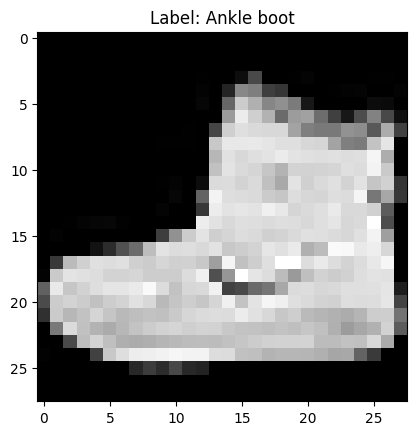

In [18]:
#Basic Data Visualisation 
img=X_train[0,:,:] 
label=y_train[0] 
plt.imshow(img, cmap='gray' ) 

plt.title(f"Label: {label_mapping[label]}") 
plt.show()

## Task 2 — Data Preprocessing
    Prepare the dataset for CNN training.
    Students must:
    Normalize pixel values (0–255 → 0–1)
    Reshape images to CNN format
    Expected shape:
    (28, 28, 1)
    Also convert labels to one-hot encoding.

### Data Preprocessing

In [19]:
# Normalize and reshape
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32')/255
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32')/255

# one-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Task 3 — Visualize Class Distribution
    Students must:
    Count number of images in each class
    Plot bar chart of class distribution
    Goal:
    Check whether the dataset is balanced.

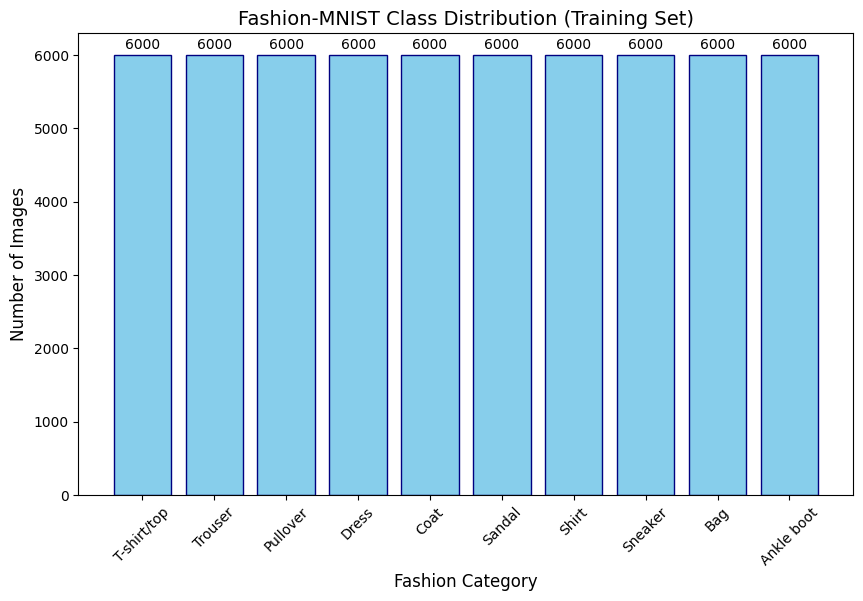

Is the dataset perfectly balanced? True


In [24]:
# Task 3: Visualize Class Distribution

# 1. Count number of images in each class
# Since y_train is one-hot encoded, we take the argmax to get the original class integer
y_train_integers = np.argmax(y_train, axis=1)
unique, counts = np.unique(y_train_integers, return_counts=True)

# 2. Map integer counts to class names
class_names = [label_mapping[i] for i in unique]

# 3. Plot bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, counts, color='skyblue', edgecolor='navy')

# Add labels and title
plt.xlabel('Fashion Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Fashion-MNIST Class Distribution (Training Set)', fontsize=14)
plt.xticks(rotation=45)

# Add count labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom')

plt.show()

# 4. Check for balance
is_balanced = np.all(counts == counts[0])
print(f"Is the dataset perfectly balanced? {is_balanced}")

## Task 4 — Build First CNN Architecture
    Students must implement a CNN with this architecture:
    Input (28x28x1)
    ↓
    Conv2D (32 filters, 3x3)
    ↓
    ReLU
    ↓
    MaxPooling (2x2)
    ↓
    Conv2D (64 filters, 3x3)
    ↓
    ReLU
    ↓
    MaxPooling (2x2)
    ↓
    Flatten
    ↓
    Dense (128)
    ↓
    Softmax (10)
    Goal:
    Understand basic CNN architecture.

### Model Building

In [21]:
model=Sequential([
Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),#Convolution layer-detects patterns. 
MaxPooling2D(pool_size=(2,2)),#Pooling layer>reduces spatial dimensions. 
Conv2D(64,kernel_size=(3,3),activation='relu'),#Convolution layer>detects patterns. 
MaxPooling2D(pool_size=(2,2)),#Pooling layer+reduces spatial dimensions. 
Flatten(), 
Dense(128,activation='relu'), 
Dense(10, activation='softmax') ])
model. summary()  

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Task 5 — Model Compilation
    Students must compile the model using:
    Optimizer → Adam
    Loss → categorical crossentropy
    Metrics → accuracy
    Goal:

    Understand how models are configured before training.
 

### Model Compilation

In [22]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

## Task 6 — Train the Model
    Train the CNN with:
    Epochs = 10
    Batch size = 64
    Validation split = 20%
    Students must:
    Plot training accuracy vs validation accuracy
    Plot training loss vs validation loss
    Goal:

    Observe model learning behaviour.

### Training the Model

In [23]:
history=model.fit(X_train,y_train, epochs=10,batch_size=32,validation_split=0.2) 
# epochs-> Model sees dataset 5 times. 
# Batch_size=Processes 128 images per step. 
# #validation_split ->Uses 20% of training data for validation.

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.7637 - loss: 0.6596 - val_accuracy: 0.8686 - val_loss: 0.3631
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.8788 - loss: 0.3295 - val_accuracy: 0.8919 - val_loss: 0.2936
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8982 - loss: 0.2761 - val_accuracy: 0.8945 - val_loss: 0.2855
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9131 - loss: 0.2394 - val_accuracy: 0.8984 - val_loss: 0.2699
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9211 - loss: 0.2114 - val_accuracy: 0.9107 - val_loss: 0.2614
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9333 - loss: 0.1829 - val_accuracy: 0.8943 - val_loss: 0.2844
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9385 - loss: 0.1658 - val_accuracy: 0.9143 - val_loss: 0.2465
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9470 -

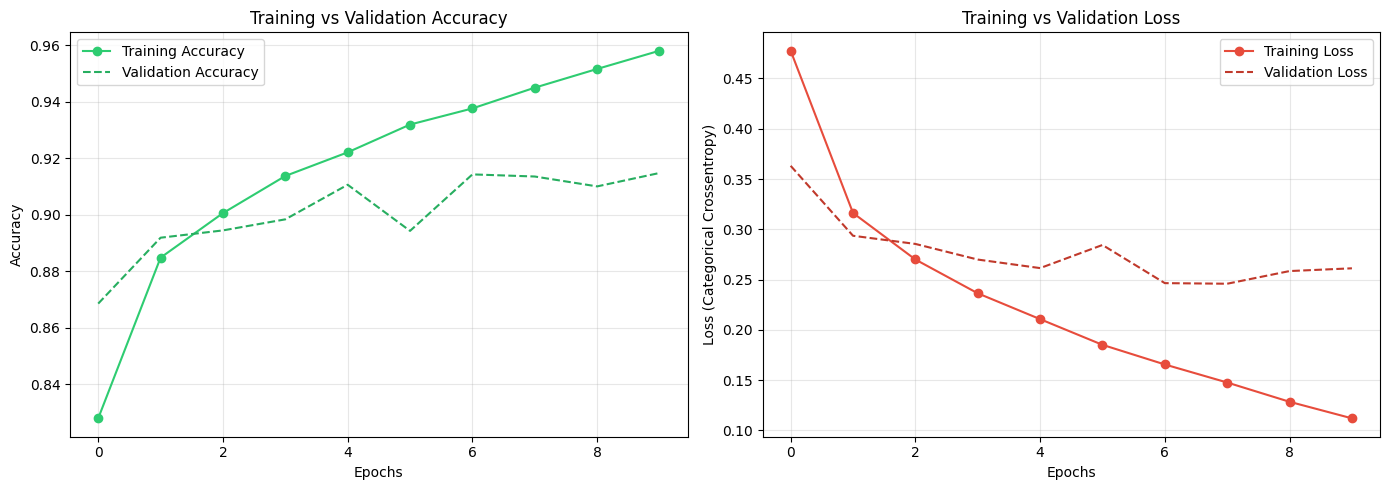

In [27]:
# 1. Create a figure with two subplots
plt.figure(figsize=(14, 5))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#2ecc71', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#27ae60', linestyle='--')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#e74c3c', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#c0392b', linestyle='--')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 7 — Model Evaluation
    Evaluate model performance on test dataset.
    Students must print:
    Test accuracy
    Test loss
    Then display 5 test images with predictions.
    Goal:
    Understand how models generalize to unseen data.

### Test Model

In [25]:
test_loss, test_accuracy=model.evaluate(X_test,y_test) 
print(f"Test Loss: {test_loss}") 
print(f"Test Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9086 - loss: 0.2967
Test Loss: 0.2835730314254761
Test Accuracy: 0.9103000164031982


### predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


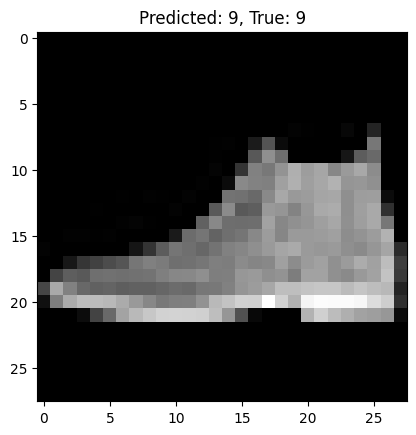

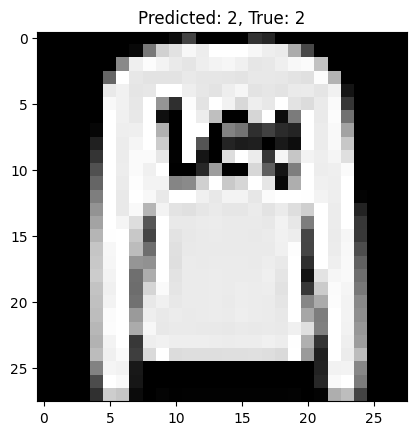

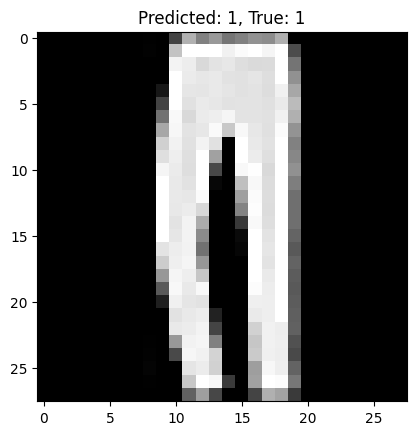

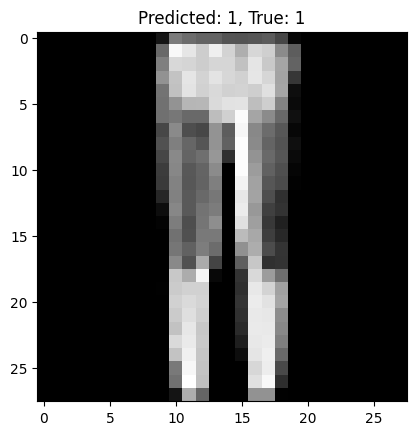

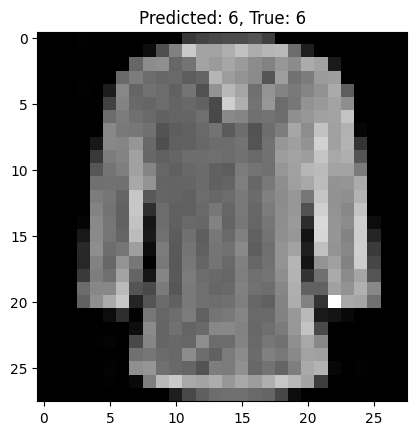

In [32]:
#Predict on the few test samples
predictions=model.predict(X_test[:5])
predicted_classess=np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test[:5], axis=1)

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28),cmap='gray')
    plt.title(f"Predicted: {predicted_classess[i]}, True: {true_classes[i]}")
    plt.show()

## Task 8 — Confusion Matrix Analysis
    Students must:
    Generate confusion matrix
    Visualize using heatmap
    Goal:
    Understand which classes are misclassified.
    Example challenge:
    Shirt vs T-shirt
    Sneaker vs Ankle Boot
    These are commonly confused.

## confusion matrix

In [34]:
# 1. Get predictions for the test set
y_pred = model.predict(X_test)

# 2. Convert one-hot encoded predictions and true labels back to integers
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 3. Create the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
[[863   0  23  19   5   1  86   0   3   0]
 [  4 978   3   9   3   0   2   0   1   0]
 [  7   0 936   8  26   0  23   0   0   0]
 [ 16   3  15 906  42   1  14   0   3   0]
 [  4   0  86  11 842   0  56   0   1   0]
 [  0   0   0   0   0 985   0  10   0   5]
 [114   0  99  25  63   0 695   0   3   1]
 [  0   0   0   0   0  15   0 962   0  23]
 [  8   0   4   3   4   2   2   2 975   0]
 [  0   0   1   0   0   9   0  29   0 961]]


### HeatMap

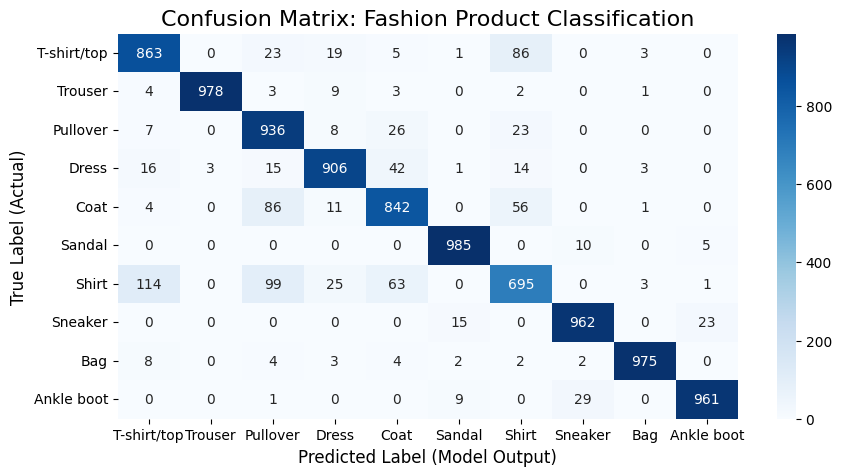

In [37]:
# 4. Define the class names for the axes
classes = [label_mapping[i] for i in range(10)]

# 5. Plot the heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

plt.title('Confusion Matrix: Fashion Product Classification', fontsize=16)
plt.ylabel('True Label (Actual)', fontsize=12)
plt.xlabel('Predicted Label (Model Output)', fontsize=12)
plt.show()

## Task 9 — Improve the CNN Architecture
    Students must modify the architecture by:
    Adding Dropout layer
    Increasing filters
    Adding another convolution layer
    Example:
    Conv → Conv → Pool → Conv → Pool
    Then compare:
    Model 1 accuracy vs Model 2 accuracy
    Goal:
    Understand model improvement strategies.

### building the model 2

In [39]:
# Model 2: Improved Architecture
model_2 = Sequential([
    # Block 1: Double Convolution
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25), # Regularization to prevent overfitting

    # Block 2: Increased Filters
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile Model 2
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model 2
history_2 = model_2.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 94s 123ms/step - accuracy: 0.6973 - loss: 0.8299 - val_accuracy: 0.8716 - val_loss: 0.3447
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - accuracy: 0.8615 - loss: 0.3737 - val_accuracy: 0.8975 - val_loss: 0.2828
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 121ms/step - accuracy: 0.8868 - loss: 0.3065 - val_accuracy: 0.9044 - val_loss: 0.2546
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 140s 119ms/step - accuracy: 0.8972 - loss: 0.2812 - val_accuracy: 0.9055 - val_loss: 0.2543
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 94s 126ms/step - accuracy: 0.9060 - loss: 0.2584 - val_accuracy: 0.9172 - val_loss: 0.2258
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 139s 122ms/step - accuracy: 0.9116 - loss: 0.2429 - val_accuracy: 0.9168 - val_loss: 0.2221
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.9196 - loss: 0.2227 - val_accuracy: 0.9218 - val_loss: 0.2150
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 145s 124ms/step - accuracy: 0.9213 - loss: 0.2117 -

In [40]:
# Evaluate both models
score_1 = model.evaluate(X_test, y_test, verbose=0)
score_2 = model_2.evaluate(X_test, y_test, verbose=0)

print(f"Model 1 (Basic) Test Accuracy: {score_1[1]*100:.2f}%")
print(f"Model 2 (Improved) Test Accuracy: {score_2[1]*100:.2f}%")

Model 1 (Basic) Test Accuracy: 91.03%
Model 2 (Improved) Test Accuracy: 91.47%


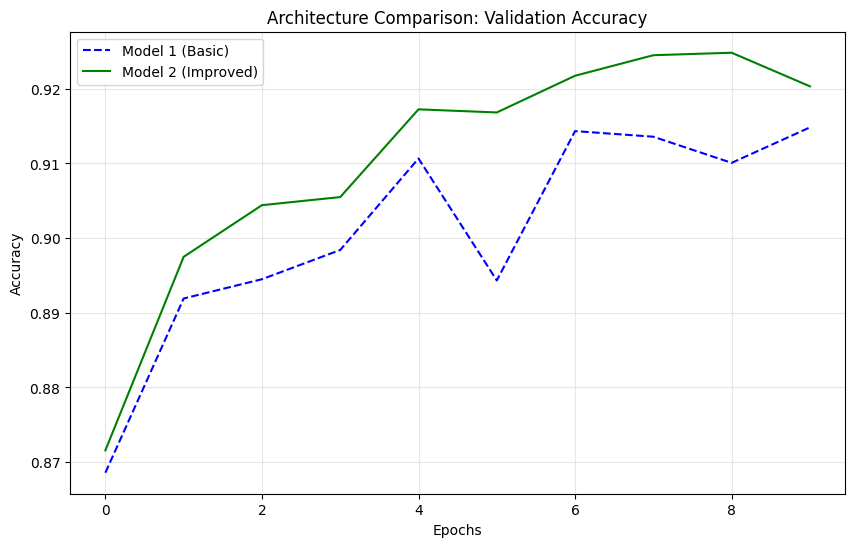

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Model 1 (Basic)', color='blue', linestyle='--')
plt.plot(history_2.history['val_accuracy'], label='Model 2 (Improved)', color='green')

plt.title('Architecture Comparison: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 10 — Misclassification Analysis
    Students must:
    Identify 5 wrongly predicted images
    Display:
    Actual label
    Predicted label
    Then explain:
    Why might the model confuse these classes?
    Goal:

    Develop model debugging skills.
 

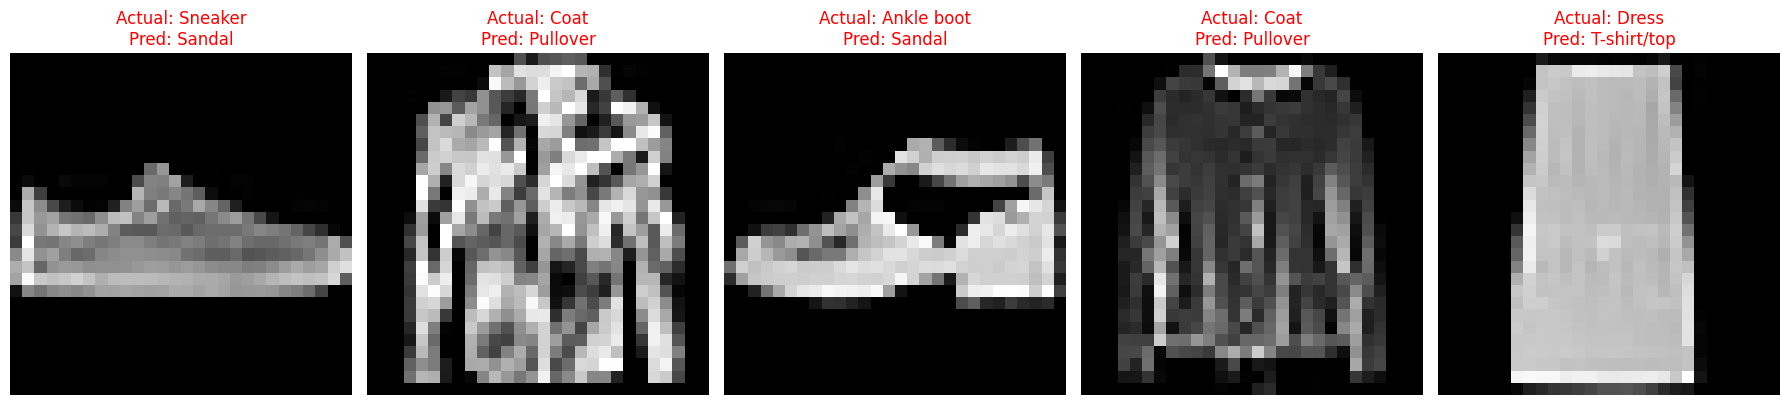

In [42]:
# Find indices of misclassified images
misclassified_indices = np.where(y_pred_classes != y_true_classes)[0]

# Select the first 5 for analysis
sample_indices = misclassified_indices[:5]

# Plot the results
plt.figure(figsize=(18, 5))

for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    
    actual = label_mapping[y_true_classes[idx]]
    predicted = label_mapping[y_pred_classes[idx]]
    
    plt.title(f"Actual: {actual}\nPred: {predicted}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Task 11 — Feature Map Visualization 
    Students must:
    Extract intermediate CNN layer outputs
    Visualize feature maps for one image
    Goal:

    Understand what CNN learns internally.
 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


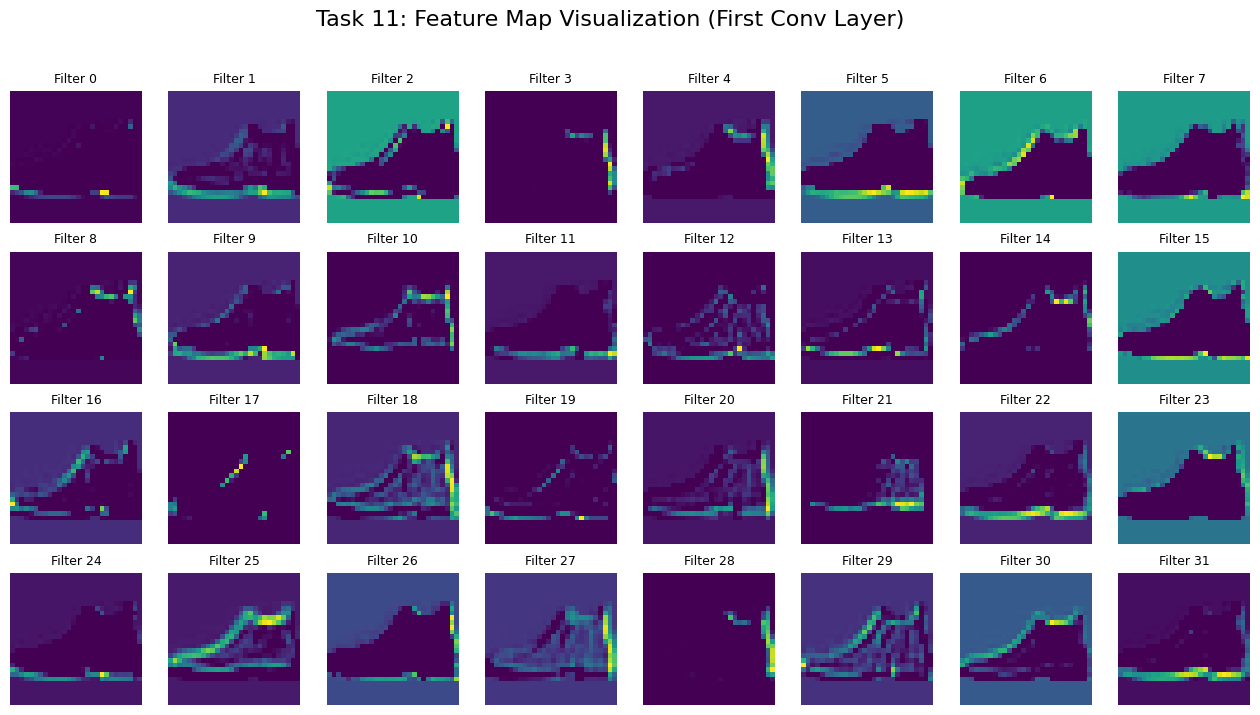

In [45]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

# 1. Re-verify the model has been built by calling it on real data
# (If you already trained model_2, this is just to be safe)
_ = model_2.predict(X_test[:1])

# 2. Use the input from the very first layer instead of the Sequential wrapper
# This avoids the "Sequential has no input" attribute error
input_tensor = model_2.layers[0].input
layer_outputs = [layer.output for layer in model_2.layers[:4]]

# 3. Create the visualization model
visual_model = Model(inputs=input_tensor, outputs=layer_outputs)

# 4. Pick an image (Ankle Boot at index 0)
test_img = X_test[0].reshape(1, 28, 28, 1)

# 5. Get the feature maps (activations)
activations = visual_model.predict(test_img)

# 6. Visualize the 32 filters of the First Convolutional Layer
first_layer_activation = activations[0] 

plt.figure(figsize=(16, 8))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    # Extract the i-th channel/filter
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f"Filter {i}", fontsize=9)

plt.suptitle("Task 11: Feature Map Visualization (First Conv Layer)", fontsize=16)
plt.show()

## Task 12 — Build Simple Prediction Interface
    Students must write code that:
    Takes a random test image
    Predicts class
    Displays predicted label with probability
    Goal:

    Simulate real-world inference.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


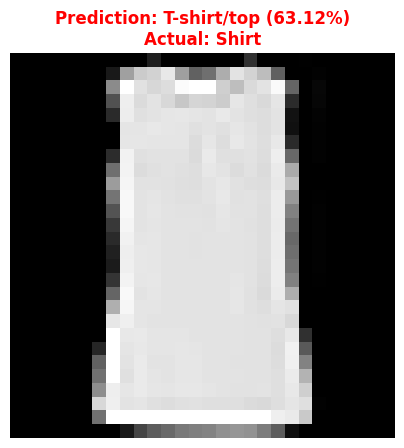

In [46]:
def predict_fashion_item(model, images, labels):
    # 1. Select a random image
    idx = np.random.randint(0, len(images))
    img = images[idx]
    true_label = label_mapping[np.argmax(labels[idx])]
    
    # 2. Perform Inference
    prediction = model.predict(img.reshape(1, 28, 28, 1))
    predicted_class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    predicted_label = label_mapping[predicted_class_idx]
    
    # 3. Display Result
    plt.figure(figsize=(5, 5))
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
    
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)\nActual: {true_label}", 
              color=color, fontsize=12, fontweight='bold')
    plt.show()

# Run the simulation
predict_fashion_item(model_2, X_test, y_test)